<a href="https://colab.research.google.com/github/Harshithpalan/Python-projects/blob/main/Crop%20Yield%20Prediction%20System%20Predict%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup and Data Loading

First, we'll import the necessary libraries and prepare to load our data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Dataset

Now, we'll load the dataset. Please ensure your dataset file is available in the Colab environment. If not, you might need to upload it or provide a link to it.

In [4]:
# Using 'california_housing_train.csv' from the sample data as a placeholder.
# You can replace this with your actual crop yield dataset when available.
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded successfully with 17000 rows and 9 columns.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


### Initial Data Inspection

Let's get a quick overview of the dataset, including its structure, data types, and a summary of its statistical properties.

In [5]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [6]:
print("\nDescriptive Statistics:")
df.describe()


Descriptive Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
print("\nMissing Values per Column:")
df.isnull().sum()


Missing Values per Column:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


### Data Visualization

Visualizing the data helps us understand the distribution of features and identify potential relationships. We'll start with histograms and a correlation heatmap.

Generating histograms for numerical features...


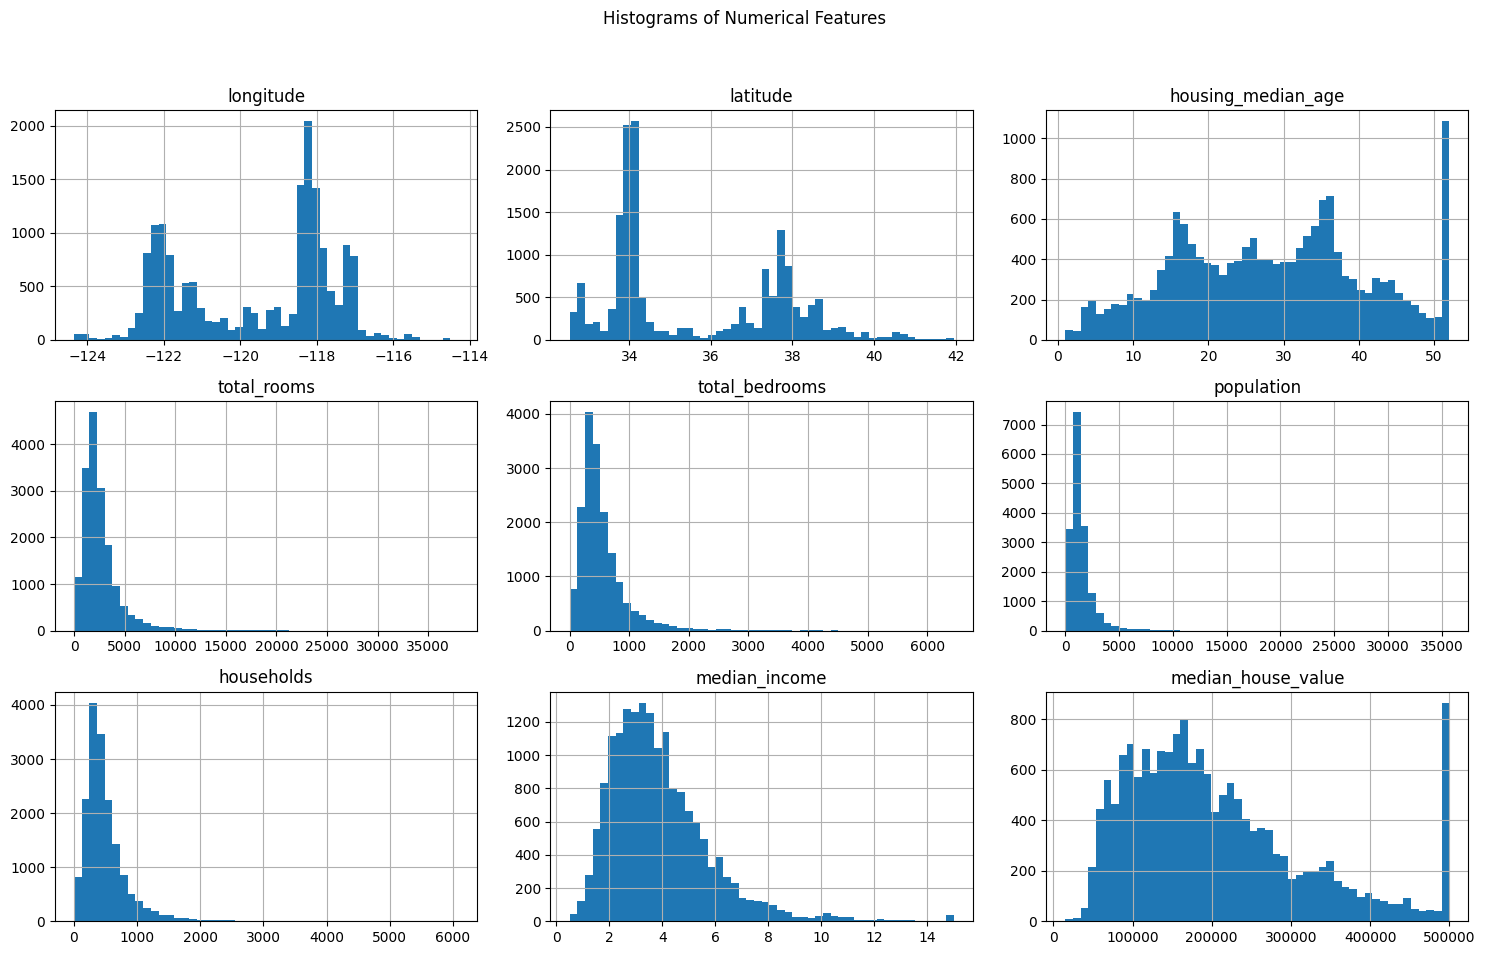

In [8]:
print("Generating histograms for numerical features...")
df.hist(figsize=(15, 10), bins=50)
plt.suptitle('Histograms of Numerical Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generating correlation heatmap...


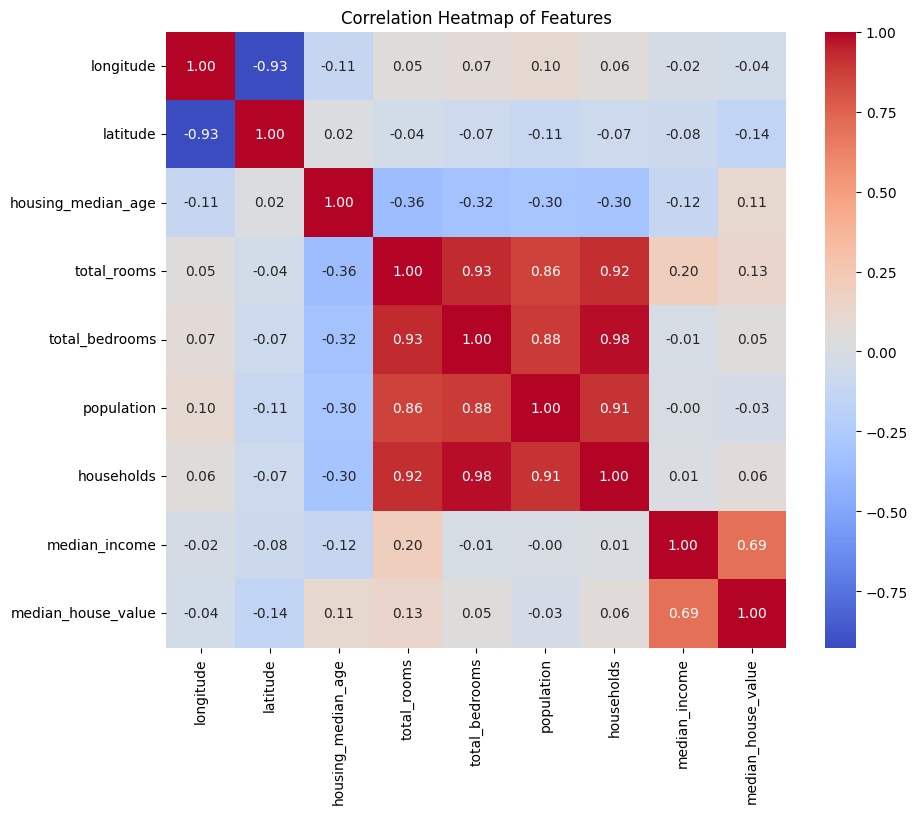

In [9]:
print("Generating correlation heatmap...")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()

### Data Preprocessing and Feature Engineering

Based on our initial exploration, let's create some new features that might be helpful for our model. We'll derive new features from existing ones to capture more complex relationships in the data.

In [10]:
print("Creating new features...")

df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

print("New features created. Displaying head of DataFrame with new features:")
df.head()

Creating new features...
New features created. Displaying head of DataFrame with new features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,11.889831,0.228617,2.150424
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,16.522678,0.248497,2.438445
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,6.153846,0.241667,2.846154
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,6.641593,0.224517,2.278761
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,5.549618,0.224209,2.381679


In [11]:
print("Re-examining descriptive statistics with new features:")
df.describe()

Re-examining descriptive statistics with new features:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353,5.439044,0.212760,2.976337
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387,2.539196,0.057823,4.037838
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,0.692308
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000,4.445275,0.175058,2.432609
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000,5.236106,0.202943,2.816872
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000,6.058097,0.239867,3.279435
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091,1.000000,502.461538


### Data Preparation for Model Training

Before training a machine learning model, we need to prepare our data. This involves separating the features (independent variables) from the target (dependent variable) and splitting the dataset into training and testing sets.

In [12]:
# Define features (X) and target (y)
# For the California Housing dataset, 'median_house_value' is the typical target.
# You would replace 'median_house_value' with your crop yield target column name.

TARGET_COLUMN = 'median_house_value'
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

X.head()

Features (X) shape: (17000, 11)
Target (y) shape: (17000,)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,11.889831,0.228617,2.150424
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,16.522678,0.248497,2.438445
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,6.153846,0.241667,2.846154
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,6.641593,0.224517,2.278761
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,5.549618,0.224209,2.381679


In [13]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# We'll use a test size of 20% and a random state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (13600, 11)
X_test shape: (3400, 11)
y_train shape: (13600,)
y_test shape: (3400,)


### Model Training and Evaluation

Now we'll train a machine learning model using our prepared training data and then evaluate its performance on the test set. We'll start with a simple Linear Regression model.

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Training a Linear Regression model...")

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully. Now making predictions on the test set...")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Training a Linear Regression model...
Model trained successfully. Now making predictions on the test set...

Model Evaluation:
Mean Squared Error (MSE): 4552463037.86
Root Mean Squared Error (RMSE): 67471.94
R-squared (R2): 0.67


### Feature Scaling

Linear models often perform better when numerical input variables are scaled. We will use `StandardScaler` to standardize our features, transforming them to have a mean of 0 and a standard deviation of 1.

In [15]:
from sklearn.preprocessing import StandardScaler

print("Applying StandardScaler to features...")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully. Displaying a sample of scaled training data:")
print(X_train_scaled[:5])

Applying StandardScaler to features...
Features scaled successfully. Displaying a sample of scaled training data:
[[ 0.74182975 -0.84715727 -0.52839839  0.03311057 -0.44516516 -0.1093373
  -0.34660377  2.44336202  0.72085493 -1.42753341  0.12399458]
 [ 0.96140556 -0.99243346 -1.32221004  0.45186696 -0.00831677  0.06388797
  -0.02353959  1.74194208  0.71667761 -1.11443059  0.01578357]
 [ 1.23088496 -1.42826202 -0.92530422 -1.01239685 -1.08381852 -0.92634004
  -1.07870889  0.66656067 -0.1266074  -0.4488326   0.24826989]
 [ 1.19595244 -1.31579014  0.42417559 -0.16796628 -0.39055912 -0.35409339
  -0.31794485 -0.12456603  0.21006752 -0.82768913 -0.06607254]
 [ 0.74182975 -0.67844944  0.58293792 -0.10340032 -0.34544977 -0.18690085
  -0.22936273  0.87289146  0.15196467 -0.85662677 -0.01077453]]


### Retraining Model with Scaled Data

Now, let's retrain the Linear Regression model using the scaled features and evaluate its performance again.

In [16]:
print("Retraining Linear Regression model with scaled data...")

# Initialize and train the model with scaled data
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

print("Scaled model trained successfully. Now making predictions on the scaled test set...")

# Make predictions on the scaled test set
y_pred_scaled = model_scaled.predict(X_test_scaled)

# Evaluate the scaled model
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"\nScaled Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse_scaled:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_scaled:.2f}")
print(f"R-squared (R2): {r2_scaled:.2f}")

Retraining Linear Regression model with scaled data...
Scaled model trained successfully. Now making predictions on the scaled test set...

Scaled Model Evaluation:
Mean Squared Error (MSE): 4552463037.86
Root Mean Squared Error (RMSE): 67471.94
R-squared (R2): 0.67
